In [1]:
# Module 1 : Importing Data Sets

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

filepath='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'
columns = ['id','date','price','bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','grade','sqft_above','sqft_basement','yr_built','yr_renovated','zipcode','lat','long','sqft_living15','sqft_lot15']

df = pd.read_csv(filepath)
df

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,21608,263000018,20140521T000000,360000.0,3.0,2.50,1530,1131,3.0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,21609,6600060120,20150223T000000,400000.0,4.0,2.50,2310,5813,2.0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,21610,1523300141,20140623T000000,402101.0,2.0,0.75,1020,1350,2.0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,21611,291310100,20150116T000000,400000.0,3.0,2.50,1600,2388,2.0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [2]:
# Question 1
# Display the data types of each column using the function dtypes. Take a screenshot of your code and output. You will need to submit the screenshot for the final project. 

df.dtypes

Unnamed: 0         int64
id                 int64
date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [3]:
# Module 2 : Data Wrangling

# Question 2
# Drop the columns "id" and "Unnamed: 0" from axis 1 using the method drop(), then use the method describe() to obtain a statistical summary of the data. 
# Make sure the inplace parameter is set to True. Take a screenshot of your code and output. You will need to submit the screenshot for the final project. 
df.drop(['id','Unnamed: 0'], axis=1, inplace=True)
df


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,20140521T000000,360000.0,3.0,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,20150223T000000,400000.0,4.0,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,20140623T000000,402101.0,2.0,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,20150116T000000,400000.0,3.0,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [4]:
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of NaN values for the column bedrooms : 13
number of NaN values for the column bathrooms : 10


In [5]:
mean=df['bedrooms'].mean()
df['bedrooms'] = df['bedrooms'].replace(np.nan,mean)

In [6]:
mean=df['bathrooms'].mean()
df['bathrooms'] = df['bathrooms'].replace(np.nan,mean)

In [7]:
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of NaN values for the column bedrooms : 0
number of NaN values for the column bathrooms : 0


In [8]:
# Module 3 : Exploratory Data Analysis

# Question 3
# Use the method value_counts to count the number of houses with unique floor values, use the method .to_frame() to convert it to a data frame. 
# Take a screenshot of your code and output. You will need to submit the screenshot for the final project.

df_floors_count = df[['floors']].value_counts().to_frame()
df_floors_count

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


<Axes: xlabel='waterfront', ylabel='price'>

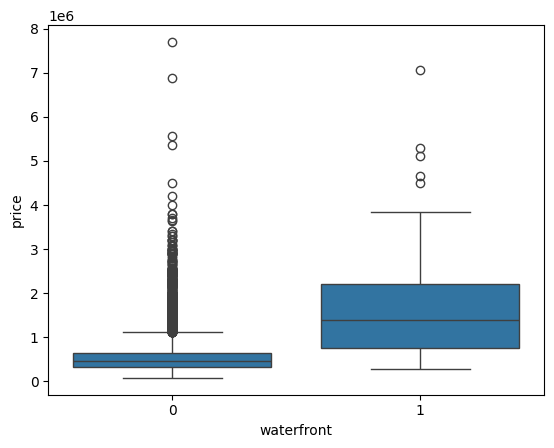

In [9]:
# Question 4
# Use the function boxplot in the seaborn library to determine whether houses with a waterfront view or without a waterfront view have more price outliers. 
# Take a screenshot of your code and boxplot. You will need to submit the screenshot for the final project. 
sns.boxplot(x='waterfront',y='price', data=df)
# The boxplot shows that houses without waterfront view has more price outliers.

<Axes: xlabel='sqft_above', ylabel='price'>

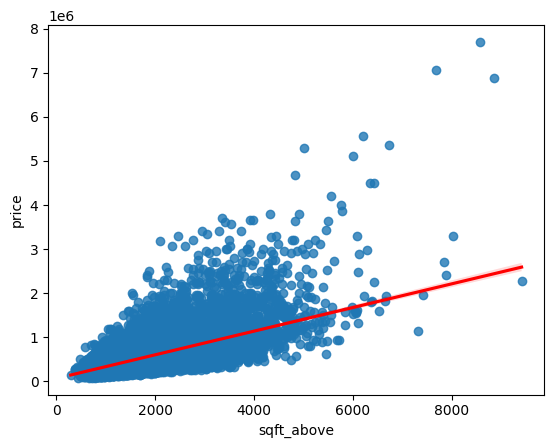

In [10]:
# Question 5
# Use the function regplot in the seaborn library to determine if the feature sqft_above is negatively or positively correlated with price. 
# Take a screenshot of your code and scatterplot. You will need to submit the screenshot for the final project. 
sns.regplot(x='sqft_above',y='price',data=df, line_kws={'color':'red'})
# As shown in the output figure, a positive slope red line shows that sqft_above is positively correlated with price.


In [11]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.corr()['price'].sort_values()

zipcode         -0.053203
long             0.021626
condition        0.036362
yr_built         0.054012
sqft_lot15       0.082447
sqft_lot         0.089661
yr_renovated     0.126434
floors           0.256794
waterfront       0.266369
lat              0.307003
bedrooms         0.308797
sqft_basement    0.323816
view             0.397293
bathrooms        0.525738
sqft_living15    0.585379
sqft_above       0.605567
grade            0.667434
sqft_living      0.702035
price            1.000000
Name: price, dtype: float64

In [12]:
# Module 4: Model Development
# We can Fit a linear regression model using the longitude feature 'long' and caculate the R^2.

lm = LinearRegression()
X = df[['long']]
Y = df[['price']]
lm.fit(X,Y)
print('The R^2 is :', lm.score(X, Y))

The R^2 is : 0.0004676943014898516


In [13]:
# Question 6
# Fit a linear regression model to predict the 'price' using the feature 'sqft_living' then calculate the R^2. 
# Take a screenshot of your code and the value of the R^2. You will need to submit it for the final project.

lm = LinearRegression()
X = df[['sqft_living']]
Y = df[['price']]
lm.fit(X,Y)
print('The R^2 is :', lm.score(X, Y))

The R^2 is : 0.4928532179037931


In [14]:
# Question 7
# Fit a linear regression model to predict the 'price' using the list of features:
features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]

lm = LinearRegression()
X = df[features]
Y = df[['price']]
lm.fit(X,Y)
print('The R^2 is :', lm.score(X, Y))

The R^2 is : 0.65769516660375


In [15]:
# Question 8
# Use the list to create a pipeline object to predict the 'price', fit the object using the features in the list features, and calculate the R^2. 
# Take a screenshot of your code and the value of the R^2. You will need to submit it for the final project.

Input = [('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe = Pipeline(Input)
X = X.astype(float)
pipe.fit(X,Y)
ypipe = pipe.predict(X)
print('The R^2 is :', r2_score(Y, ypipe))

The R^2 is : 0.7513408515988733


In [16]:
# Module 5 : Model Evaluation and Refinement

features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]    
X = df[features]
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)


print("number of test samples:", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples: 3242
number of training samples: 18371


In [17]:
# Question 9
# Create and fit a Ridge regression object using the training data, set the regularization parameter to 0.1, and calculate the R^2 using the test data. 
# Take a screenshot of your code and the value of the R^2. You will need to submit it for the final project.

RidgeModel = Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print(f"test set: {RidgeModel.score(x_test, y_test)}")

test set: 0.6478759163939113


In [18]:
# Question 10
# Perform a second order polynomial transform on both the training data and testing data. 
# Create and fit a Ridge regression object using the training data, set the regularisation parameter to 0.1, and calculate the R^2 utilising the test data provided. 
# Take a screenshot of your code and the R^2. You will need to submit it for the final project.


pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr  = pr.fit_transform( x_test)

RigeModel = Ridge(alpha=0.1) 
RigeModel.fit(x_train_pr, y_train)
test_score = RigeModel.score(x_train_pr, y_train)
print("test data R^2 : ", test_score)




test data R^2 :  0.7418167438677382
